# Multivariate Gaussian Model Application

### Standard Gaussian Model

In [1]:
from utils import *
from gaussian_utils import *
import numpy as np

D, L = load("train_data.txt")
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L)

parameters = compute_theta_parameters_per_class(D_training, L_training)

scores = compute_ll_per_class(D_eval, parameters) 

Pc0 = (1/2) # prior class 0
Pc1 = (1/2) # prior class 1

threshold = - (np.log(Pc1/Pc0))

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.93
Error rate: 0.07


### Tied Gaussian Model

In this model we will use the same (mean) covariance matrix

In [2]:
C = (parameters[0][1]*(L_training == 0).sum()  \
    + parameters[1][1]*(L_training == 1).sum()) \
    / L_training.shape[0] # weighted mean covariance matrix : (C1*samples1 + C2*samples2) / tot_samples)

parameters_tied = [(parameters[0][0], C), (parameters[1][0], C)]

scores = compute_ll_per_class(D_eval, parameters_tied) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.91
Error rate: 0.09


### Naive Gaussian Model

Now we consider zero covariance between features

In [3]:
naive_parameters = []

for i in range(2):
    cov_mat = parameters[i][1] * np.identity(parameters[i][1].shape[0]) # A * I to obtain only diagona elements
    naive_parameters.append((parameters[i][0], cov_mat))

scores = compute_ll_per_class(D_eval, naive_parameters) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.93
Error rate: 0.07


### Why Naive performs like the standard model?

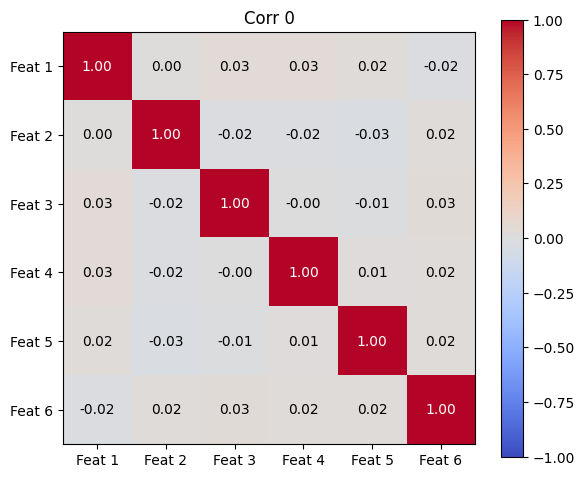

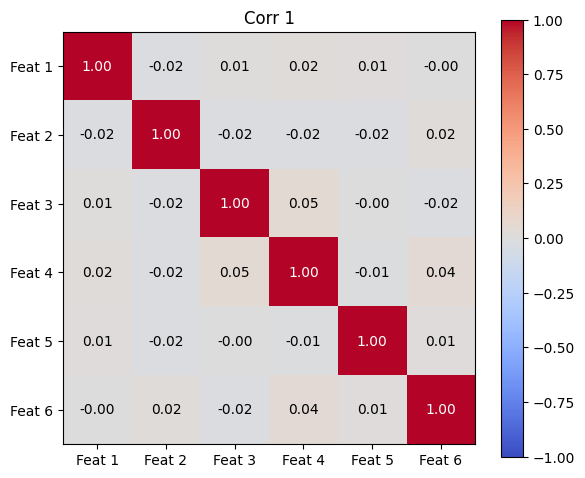

In [4]:
C0 = parameters[0][1]
C1 = parameters[1][1]

Corr_0 = C0 / (vcol(C0.diagonal()**0.5) * vrow(C0.diagonal()**0.5))
Corr_1 = C1 / (vcol(C1.diagonal()**0.5) * vrow(C1.diagonal()**0.5))

print_corr(Corr_0, title="Corr 0")
print_corr(Corr_1, title="Corr 1")


### Trying classification without features 5 and 6

We will now remove feature 5 and 6 beacause they don't perfectly fit standard distribution assumptions.
In order:
- Standard Gaussian Model
- Tied Gaussian Model
- Naive Gaussian Model

In [5]:
D = D[:4, :]
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L)

parameters = compute_theta_parameters_per_class(D_training, L_training)

scores = compute_ll_per_class(D_eval, parameters) 

Pc0 = (1/2) # prior class 0
Pc1 = (1/2) # prior class 1

threshold = - (np.log(Pc1/Pc0))

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.92
Error rate: 0.08


In [6]:
C = (parameters[0][1]*(L_training == 0).sum()  \
    + parameters[1][1]*(L_training == 1).sum()) \
    / L_training.shape[0] # weighted mean covariance matrix : (C1*samples1 + C2*samples2) / tot_samples)

parameters_tied = [(parameters[0][0], C), (parameters[1][0], C)]

scores = compute_ll_per_class(D_eval, parameters_tied) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.91
Error rate: 0.09


In [7]:
naive_parameters = []

for i in range(2):
    cov_mat = parameters[i][1] * np.identity(parameters[i][1].shape[0]) # A * I to obtain only diagona elements
    naive_parameters.append((parameters[i][0], cov_mat))

scores = compute_ll_per_class(D_eval, naive_parameters) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.92
Error rate: 0.08


The accuracy drops!

## Applying PCA before the model

In [9]:
from dimensionality_reduction import *

D, L = load("train_data.txt")
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L)

num_target_dimensions = 5

U = PCA(D_training, num_target_dimensions)
D_training = U.T@D_training
D_eval = U.T@D_eval

parameters = compute_theta_parameters_per_class(D_training, L_training)

scores = compute_ll_per_class(D_eval, parameters) 

Pc0 = (1/2) # prior class 0
Pc1 = (1/2) # prior class 1

threshold = - (np.log(Pc1/Pc0))

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.93
Error rate: 0.07


In [11]:
C = (parameters[0][1]*(L_training == 0).sum()  \
    + parameters[1][1]*(L_training == 1).sum()) \
    / L_training.shape[0] # weighted mean covariance matrix : (C1*samples1 + C2*samples2) / tot_samples)

parameters_tied = [(parameters[0][0], C), (parameters[1][0], C)]

scores = compute_ll_per_class(D_eval, parameters_tied) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.91
Error rate: 0.09


In [10]:
naive_parameters = []

for i in range(2):
    cov_mat = parameters[i][1] * np.identity(parameters[i][1].shape[0]) # A * I to obtain only diagona elements
    naive_parameters.append((parameters[i][0], cov_mat))

scores = compute_ll_per_class(D_eval, naive_parameters) 

log_likelihood_ratios = scores[1, :] - scores[0, :]

predictions = log_likelihood_ratios >= threshold

accuracy = ((predictions == L_eval).sum()) / L_eval.shape[0]

print(f"Accuracy: {accuracy:.2f}")
print(f"Error rate: {(1-accuracy):.2f}")

Accuracy: 0.91
Error rate: 0.09
